In [1]:
import os
import gc
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

In [2]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)

cuda


In [3]:
!git clone https://github.com/gasvn/Res2Net.git

Cloning into 'Res2Net'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 136 (delta 10), reused 0 (delta 0), pack-reused 118 (from 1)
Receiving objects: 100% (136/136), 64.37 KiB | 998.00 KiB/s, done.
Resolving deltas: 100% (81/81), done.


In [4]:
import sys

sys.path.append('/kaggle/working/Res2Net')

from res2net import res2net50

In [5]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Augmented Sub-datasets/AISSLab-v5/"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=224)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=224)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=224)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=224)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=224)

In [6]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 72
Shape: (72, 224, 224, 3)
Total images loaded: 192
Shape: (192, 224, 224, 3)
Total images loaded: 224
Shape: (224, 224, 224, 3)
Total images loaded: 176
Shape: (176, 224, 224, 3)


In [7]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [8]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]


X = X.astype(np.float32)

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=11,
    stratify=Y
)

In [9]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=11,
    stratify=y_train
)
print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (424, 224, 224, 3)
y_train: (424,)
x_val: (107, 224, 224, 3)
y_val: (107,)
x_test: (133, 224, 224, 3)
y_test: (133,)


In [10]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import numpy as np

print("Original class distribution:")
print(Counter(y_train))

# Flatten image data
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 1200

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train
)

# Restore shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

print("\nBalanced class distribution:")
print(Counter(y_train))

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

Original class distribution:
Counter({np.int64(2): 143, np.int64(1): 122, np.int64(3): 113, np.int64(0): 46})

Balanced class distribution:
Counter({np.int64(1): 1200, np.int64(3): 1200, np.int64(2): 1200, np.int64(0): 1200})
x_train: (4800, 224, 224, 3)
y_train: (4800,)


In [11]:
# Using original generator
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0,translate=(0.2, 0.2),shear=20),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

BATCH_SIZE = 32

In [12]:
model = res2net50(pretrained=True)

print(model)

Downloading: "https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_26w_4s-06e79181.pth" to /root/.cache/torch/hub/checkpoints/res2net50_26w_4s-06e79181.pth


100%|██████████| 98.3M/98.3M [00:01<00:00, 58.2MB/s]


Res2Net(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottle2neck(
      (conv1): Conv2d(64, 104, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(104, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool): AvgPool2d(kernel_size=3, stride=1, padding=1)
      (convs): ModuleList(
        (0-2): 3 x Conv2d(26, 26, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (bns): ModuleList(
        (0-2): 3 x BatchNorm2d(26, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv3): Conv2d(104, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

In [13]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features,4)

model = model.to(device)
print(model.fc)

Linear(in_features=2048, out_features=4, bias=True)


In [14]:
# Freeze all
for param in model.parameters():
    param.requires_grad = False

# Train only FC
for param in model.fc.parameters():
    param.requires_grad = True

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=5e-5
)

In [16]:
from torch.utils.data import Dataset

class BreastDataset(Dataset):

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform:
            image = self.transform(image)
        label = int(self.labels[idx])

        return image, label

In [17]:
from torch.utils.data import DataLoader

train_dataset = BreastDataset(
    x_train,
    y_train,
    transform=train_transform
)

val_dataset = BreastDataset(
    x_val,
    y_val,
    transform=val_transform
)

test_dataset = BreastDataset(
    x_test,
    y_test,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 150
Val batches: 4
Test batches: 5


In [18]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [19]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [20]:
EPOCHS = 50

best_acc = 0
patience = 8
counter = 0

for epoch in range(EPOCHS):
    
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    # TRAIN
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # METRICS
    val_acc = 100 * correct / total

    train_acc = 100 * train_correct / train_total

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # LR Scheduler
    scheduler.step(val_loss)

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "/kaggle/working/res2net50_best.pth"
        )

        counter = 0
    else:
        counter += 1

    # Early Stopping
    if counter >= patience:
        print("Early stopping")
        break

Epoch 1/50 | Train Loss: 1.3714 | Val Loss: 1.3575 | Train Acc: 31.77% | Val Acc: 30.84%
Epoch 2/50 | Train Loss: 1.3422 | Val Loss: 1.3464 | Train Acc: 37.62% | Val Acc: 29.91%
Epoch 3/50 | Train Loss: 1.3179 | Val Loss: 1.3268 | Train Acc: 40.67% | Val Acc: 28.97%
Epoch 4/50 | Train Loss: 1.3005 | Val Loss: 1.3418 | Train Acc: 42.21% | Val Acc: 27.10%
Epoch 5/50 | Train Loss: 1.2796 | Val Loss: 1.3115 | Train Acc: 44.04% | Val Acc: 31.78%
Epoch 6/50 | Train Loss: 1.2653 | Val Loss: 1.3142 | Train Acc: 45.35% | Val Acc: 33.64%
Epoch 7/50 | Train Loss: 1.2517 | Val Loss: 1.3156 | Train Acc: 45.81% | Val Acc: 31.78%
Epoch 8/50 | Train Loss: 1.2426 | Val Loss: 1.3125 | Train Acc: 47.21% | Val Acc: 33.64%
Epoch 9/50 | Train Loss: 1.2335 | Val Loss: 1.3214 | Train Acc: 47.06% | Val Acc: 31.78%
Epoch 10/50 | Train Loss: 1.2254 | Val Loss: 1.3066 | Train Acc: 47.81% | Val Acc: 32.71%
Epoch 11/50 | Train Loss: 1.2203 | Val Loss: 1.3176 | Train Acc: 48.67% | Val Acc: 31.78%
Epoch 12/50 | Train

In [21]:
model.load_state_dict(torch.load("/kaggle/working/res2net50_best.pth"))
print("Best FC model loaded")

Best FC model loaded


In [22]:
# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

In [23]:
# RECOMPILE
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [24]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [25]:
EPOCHS = 100

best_acc = 0
patience = 8
counter = 0

for epoch in range(EPOCHS):

    # TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # METRICS
    val_acc = 100 * correct / total

    train_acc = 100 * train_correct / train_total

    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # LR Scheduler
    scheduler.step(val_loss)

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "/kaggle/working/res2net50_best.pth"
        )
        counter = 0

    else:
        counter += 1

    # Early Stopping
    if counter >= patience:
        print("Early stopping")
        break

Epoch 1/100 | Train Loss: 1.1183 | Val Loss: 1.1529 | Train Acc: 54.40% | Val Acc: 49.53%
Epoch 2/100 | Train Loss: 0.7779 | Val Loss: 0.9178 | Train Acc: 72.44% | Val Acc: 57.01%
Epoch 3/100 | Train Loss: 0.4944 | Val Loss: 0.7290 | Train Acc: 83.85% | Val Acc: 70.09%
Epoch 4/100 | Train Loss: 0.3154 | Val Loss: 0.6635 | Train Acc: 89.56% | Val Acc: 69.16%
Epoch 5/100 | Train Loss: 0.2301 | Val Loss: 0.5790 | Train Acc: 92.35% | Val Acc: 75.70%
Epoch 6/100 | Train Loss: 0.1625 | Val Loss: 0.4516 | Train Acc: 94.60% | Val Acc: 79.44%
Epoch 7/100 | Train Loss: 0.1431 | Val Loss: 0.4407 | Train Acc: 95.12% | Val Acc: 82.24%
Epoch 8/100 | Train Loss: 0.1237 | Val Loss: 0.3989 | Train Acc: 96.00% | Val Acc: 85.98%
Epoch 9/100 | Train Loss: 0.0906 | Val Loss: 0.3458 | Train Acc: 97.58% | Val Acc: 86.92%
Epoch 10/100 | Train Loss: 0.0881 | Val Loss: 0.3091 | Train Acc: 97.40% | Val Acc: 86.92%
Epoch 11/100 | Train Loss: 0.0842 | Val Loss: 0.3254 | Train Acc: 97.48% | Val Acc: 88.79%
Epoch 12

In [26]:
model.load_state_dict(torch.load("/kaggle/working/res2net50_best.pth"))

model.eval()
print("Best model loaded for testing")

Best model loaded for testing


In [27]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

Confusion matrix, without normalization
[[ 9  0  5  0]
 [ 0 29  7  3]
 [ 3  0 39  3]
 [ 0  2  2 31]]


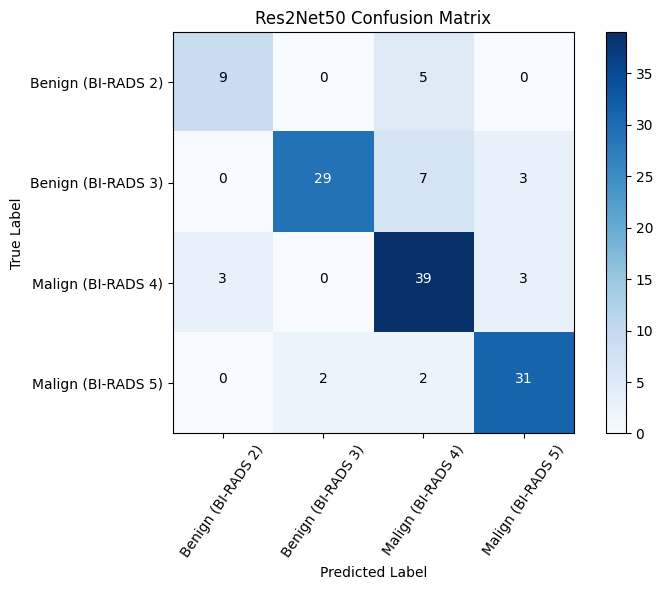

In [28]:
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# Plot Function
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    print(cm)

    plt.figure(figsize=(8,6))

    plt.imshow(cm, interpolation='nearest', cmap=cmap)

    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(
        tick_marks,
        classes,
        rotation=55
    )

    plt.yticks(
        tick_marks,
        classes
    )

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(
        range(cm.shape[0]),
        range(cm.shape[1])
    ):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# Class Names
cm_plot_label = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

# Plot
plot_confusion_matrix(
    cm,
    cm_plot_label,
    title='Res2Net50 Confusion Matrix'
)

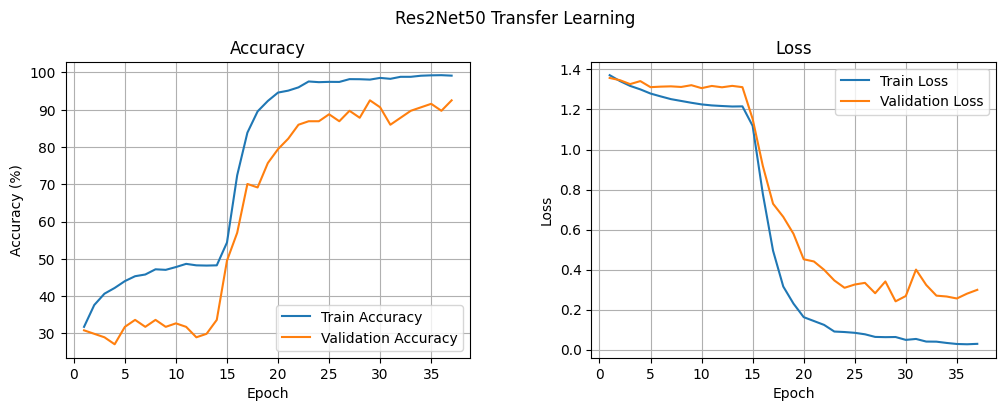

In [29]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

f.suptitle('Res2Net50 Transfer Learning',fontsize=12)
f.subplots_adjust(top=0.85,wspace=0.3)
epoch_list = range(1,len(train_accs) + 1)

# Accuracy
ax1.plot(epoch_list,train_accs,label='Train Accuracy')
ax1.plot(epoch_list,val_accs,label='Validation Accuracy')
ax1.grid()
ax1.set_ylabel('Accuracy (%)')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

# Loss
ax2.plot(epoch_list,train_losses,label='Train Loss')
ax2.plot(epoch_list,val_losses,label='Validation Loss')
ax2.grid()
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

In [30]:
import numpy as np
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,mean_absolute_error,mean_squared_error,cohen_kappa_score)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Class Names
target_names = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

print("Classification Report:")
print(classification_report(y_true,y_pred,target_names=target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true,y_pred))
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true,y_pred,average='weighted')
recall = recall_score(y_true,y_pred,average='weighted')
f1 = f1_score(y_true,y_pred,average='weighted')
mcc = matthews_corrcoef(y_true,y_pred)
mae = mean_absolute_error(y_true,y_pred)
mse = mean_squared_error(y_true,y_pred)
kappa = cohen_kappa_score(y_true,y_pred)

# Print Metrics
print("\nAdditional Evaluation Metrics:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"MCC            : {mcc:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"Cohen's Kappa  : {kappa:.4f}")

Classification Report:
                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.75      0.64      0.69        14
Benign (BI-RADS 3)       0.94      0.74      0.83        39
Malign (BI-RADS 4)       0.74      0.87      0.80        45
Malign (BI-RADS 5)       0.84      0.89      0.86        35

          accuracy                           0.81       133
         macro avg       0.81      0.78      0.79       133
      weighted avg       0.82      0.81      0.81       133

Confusion Matrix:
[[ 9  0  5  0]
 [ 0 29  7  3]
 [ 3  0 39  3]
 [ 0  2  2 31]]

Additional Evaluation Metrics:
Accuracy       : 0.8120
Precision      : 0.8227
Recall         : 0.8120
F1-score       : 0.8117
MCC            : 0.7408
MAE            : 0.2857
MSE            : 0.4812
Cohen's Kappa  : 0.7368
